# __Цифровые инструменты финансиста__

## __День 3.__ От анализа к инсайтам и прогнозам

### 21 апреля

### __1. Продвинутый анализ данных: ныряем глубже__

#### 1.1. Данные мы уже подготовили днем ранее

Возьмем датасет из прошлого семинара, собранный из данных [базы бухгалтерской отчетности](https://tochno.st/datasets/rfsd) российских предприятий.

За основу возьмем прошлый промпт, в нем уже есть описание структуры данных и образец данных:

```prompt

## Входные данные
- датафрейм `dfa` с данными бухгалтерской отчетности российских предприятий

## Задача
- протестировать гипотезу о зависимости размера компании и ее рентабельности активов и капитала от расстояния до Москвы
- для тестирования необходимо сделать колонку с расстоянием до Москвы
- расстояние рассчитать как евклидово расстояние на основе широты lat и долготы lon из данных
- координаты Москвы взять mow_lat=55.7522° mow_lon=37.6156°

## Технические ограничения
- использовать библиотеку Pandas и ее встроенные методы и функции
- настрой pandas так, чтобы выводились все столбцы, без пропусков
- код запускается в интерактивном ноутбуке Jupyter

## Технические требования
- архитектура: максимально упрощенная
- вывод данных: адаптированный под интерактивные ноутбуки, где возможно используй display вместо print 
- стиль кода: PEP 8, black (длина строки 79)
- документация: Docstrings в стиле Google

```

In [6]:
import zipfile
import pandas as pd
from pathlib import Path
from urllib.request import urlretrieve
import os

# Создаем директорию datadeep если она не существует
data_dir = Path("datadeep")
data_dir.mkdir(exist_ok=True)

# URL файла для загрузки
url = "https://storage.yandexcloud.net/tochno-st-catalog/FNS/data_rfsd_152_v20251008/by_years/data_150_rfsd_2024_v20251010_csv.zip"

# Имя файла для сохранения
zip_filename = data_dir / "data_150_rfsd_2024_v20251010_csv.zip"

print("Начинаю загрузку файла...")
# Загружаем файл
urlretrieve(url, zip_filename)
print(f"Файл загружен и сохранен в: {zip_filename}")

print("\nРаспаковываю архив...")
# Распаковываем архив
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    # Получаем список файлов в архиве
    file_list = zip_ref.namelist()
    print(f"Файлы в архиве: {file_list}")
    
    # Распаковываем все файлы в директорию datadeep
    zip_ref.extractall(data_dir)
    print(f"Архив распакован в директорию: {data_dir}")

print("\n" + "="*50)
print("Поиск файлов данных в распакованном архиве...")
print("="*50)

# Находим все CSV файлы в директории datadeep
csv_files = list(data_dir.glob("*.csv"))
if csv_files:
    print(f"\nНайдено CSV файлов: {len(csv_files)}")
    for csv_file in csv_files:
        file_size = csv_file.stat().st_size / 1024  # Размер в КБ
        print(f"  - {csv_file.name} ({file_size:.2f} KB)")
        
        # Показываем первые строки каждого CSV файла
        print(f"\nПервые строки файла {csv_file.name}:")
        df_sample = pd.read_csv(csv_file, nrows=5, sep=";")
        display(df_sample)
        print(f"Файл содержит столбцы: {list(df_sample.columns)}\n")
        print("-"*50)
else:
    print("CSV файлы не найдены. Поиск других форматов данных...")
    
    # Ищем другие потенциальные файлы данных
    data_files = list(data_dir.glob("*"))
    for file in data_files:
        if file.is_file() and file.name != zip_filename.name:
            print(f"  - {file.name}")

Начинаю загрузку файла...
Файл загружен и сохранен в: datadeep/data_150_rfsd_2024_v20251010_csv.zip

Распаковываю архив...
Файлы в архиве: ['data_150_rfsd_2024_v20251010.csv', 'description_rfsd_152_v20251008.pdf', 'financial_codes.xlsx']
Архив распакован в директорию: datadeep

Поиск файлов данных в распакованном архиве...

Найдено CSV файлов: 1
  - data_150_rfsd_2024_v20251010.csv (1399739.04 KB)

Первые строки файла data_150_rfsd_2024_v20251010.csv:


,inn,ogrn,region,region_taxcode,creation_date,dissolution_date,age,eligible,exemption_criteria,financial,...,line_6321,line_6322,line_6323,line_6324,line_6325,line_6326,line_6330,line_6350,line_6400,tbp_add
0,NaN,9047796688213,moscow city,7700,2004-09-15,NaN,20.0,1.0,none,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,100000011.0,1210100002353,adygeya,100,2021-10-27,NaN,3.0,1.0,none,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,100000043.0,1210100002364,adygeya,100,2021-10-29,NaN,3.0,1.0,none,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,0
3,100000068.0,1210100002375,adygeya,100,2021-10-29,2024-12-24,3.0,1.0,none,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,100000075.0,1210100002386,adygeya,100,2021-11-03,NaN,3.0,1.0,none,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


Файл содержит столбцы: ['inn', 'ogrn', 'region', 'region_taxcode', 'creation_date', 'dissolution_date', 'age', 'eligible', 'exemption_criteria', 'financial', 'filed', 'imputed', 'simplified', 'articulated', 'totals_adjustment', 'outlier', 'okved', 'okved_section', 'okpo', 'okopf', 'okogu', 'okfc', 'oktmo', 'lon', 'lat', 'geocoding_quality', 'line_1100', 'line_1110', 'line_1120', 'line_1130', 'line_1140', 'line_1150', 'line_1160', 'line_1170', 'line_1180', 'line_1190', 'line_1200', 'line_1210', 'line_1220', 'line_1230', 'line_1240', 'line_1250', 'line_1260', 'line_1300', 'line_1310', 'line_1320', 'line_1340', 'line_1350', 'line_1360', 'line_1370', 'line_1400', 'line_1410', 'line_1420', 'line_1430', 'line_1450', 'line_1500', 'line_1510', 'line_1520', 'line_1530', 'line_1540', 'line_1550', 'line_1600', 'line_1700', 'line_2100', 'line_2110', 'line_2120', 'line_2200', 'line_2210', 'line_2220', 'line_2300', 'line_2310', 'line_2320', 'line_2330', 'line_2340', 'line_2350', 'line_2400', 'line_2

#### 3.2. Разберемся с составом данных

Откроем и посмотрим на файл как обычно:

```prompt
## Входные данные
- путь к файлу `./datadeep/data_150_rfsd_2024_v20251010.csv`
- формат файла `csv`
- разделитель `;`

## Задача
- открыть первые 300000 строк файла и сохранить в датафрейм `df`
- вывести краткое описание данных

## Технические ограничения
- использовать библиотеку Pandas и ее встроенные методы и функции
- код запускается в интерактивном ноутбуке Jupyter

## Технические требования
- архитектура: максимально упрощенная
- вывод данных: адаптированный под интерактивные ноутбуки, где возможно используй display вместо print 
- стиль кода: PEP 8, black (длина строки 79)
- документация: Docstrings в стиле Google
```

In [7]:
import pandas as pd
import io
import sys

# Загрузка первых 100000 строк из CSV файла с разделителем ';'
df = pd.read_csv(
    './datadeep/data_150_rfsd_2024_v20251010.csv',
    sep=';',
    nrows=300000
)

# Вывод краткого описания данных в Jupyter
print("=== РАЗМЕР ДАТАФРЕЙМА ===")
print(f"Строк: {df.shape[0]:,}, Столбцов: {df.shape[1]}")
print("\n" + "="*50 + "\n")

print("=== ПЕРВЫЕ 5 СТРОК ===")
display(df.head())
print("\n" + "="*50 + "\n")

print("=== ИНФОРМАЦИЯ О ДАННЫХ ===")
# Перехватываем вывод info() в строку
buffer = io.StringIO()
df.info(buf=buffer)
info_str = buffer.getvalue()
print(info_str)
print("\n" + "="*50 + "\n")

print("=== СТАТИСТИКА ПО ЧИСЛОВЫМ СТОЛБЦАМ ===")
display(df.describe())
print("\n" + "="*50 + "\n")

print("=== ПРОВЕРКА НА ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Кол-во пропусков': missing,
    '% пропусков': missing_pct
})
# Показываем только столбцы с пропусками
missing_with_data = missing_df[missing_df['Кол-во пропусков'] > 0]
if len(missing_with_data) > 0:
    display(missing_with_data.sort_values('% пропусков', ascending=False))
else:
    print("Пропущенные значения отсутствуют")
print("\n" + "="*50 + "\n")

print("=== ТИПЫ ДАННЫХ СТОЛБЦОВ ===")
dtypes_df = pd.DataFrame({
    'Тип данных': df.dtypes,
    'Уникальных значений': df.nunique()
})
display(dtypes_df)

=== РАЗМЕР ДАТАФРЕЙМА ===
Строк: 300,000, Столбцов: 214


=== ПЕРВЫЕ 5 СТРОК ===


,inn,ogrn,region,region_taxcode,creation_date,dissolution_date,age,eligible,exemption_criteria,financial,...,line_6321,line_6322,line_6323,line_6324,line_6325,line_6326,line_6330,line_6350,line_6400,tbp_add
0,NaN,9047796688213,moscow city,7700,2004-09-15,NaN,20.0,1.0,none,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,100000011.0,1210100002353,adygeya,100,2021-10-27,NaN,3.0,1.0,none,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,100000043.0,1210100002364,adygeya,100,2021-10-29,NaN,3.0,1.0,none,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,0
3,100000068.0,1210100002375,adygeya,100,2021-10-29,2024-12-24,3.0,1.0,none,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,100000075.0,1210100002386,adygeya,100,2021-11-03,NaN,3.0,1.0,none,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0




=== ИНФОРМАЦИЯ О ДАННЫХ ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Columns: 214 entries, inn to tbp_add
dtypes: float64(204), int64(3), object(7)
memory usage: 489.8+ MB



=== СТАТИСТИКА ПО ЧИСЛОВЫМ СТОЛБЦАМ ===


,inn,ogrn,region_taxcode,age,eligible,financial,filed,imputed,simplified,articulated,...,line_6321,line_6322,line_6323,line_6324,line_6325,line_6326,line_6330,line_6350,line_6400,tbp_add
count,2.999990e+05,3.000000e+05,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.0,206920.000000,206920.000000,...,3.778000e+03,1514.000000,1354.000000,2.284000e+03,1187.000000,3.428000e+03,2.841000e+03,6.380000e+03,3.758500e+04,300000.0
mean,1.010384e+09,1.152232e+12,1038.345383,9.528187,0.988757,0.000140,0.689733,0.0,0.566494,0.947956,...,-1.050549e+04,-1253.346103,-1159.310192,-4.590043e+03,-1931.925864,-7.779379e+03,-6.455943e+03,-2.377683e+04,2.776614e+05,0.0
std,5.823544e+08,1.127074e+11,846.679982,7.921931,0.105437,0.011831,0.462603,0.0,0.495560,0.222117,...,1.635065e+05,13840.335916,22086.589914,7.771738e+04,19636.746646,2.959848e+05,6.988918e+04,6.515796e+05,3.648303e+07,0.0
min,1.000000e+08,1.001602e+12,100.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,-6.292257e+06,-332737.000000,-714058.000000,-3.495797e+06,-443929.000000,-1.706950e+07,-2.451451e+06,-4.638649e+07,-7.700809e+06,0.0
25%,3.234054e+08,1.100327e+12,300.000000,3.000000,1.000000,0.000000,0.000000,0.0,0.000000,1.000000,...,-2.008000e+03,-178.750000,-114.000000,-9.642500e+02,-212.000000,-3.510000e+02,-2.950000e+02,-8.462500e+02,0.000000e+00,0.0
50%,1.101148e+09,1.161690e+12,1100.000000,8.000000,1.000000,0.000000,1.000000,0.0,1.000000,1.000000,...,-6.395000e+02,-13.000000,-11.500000,-1.935000e+02,0.000000,-5.400000e+01,0.000000e+00,-5.600000e+01,0.000000e+00,0.0
75%,1.650325e+09,1.210500e+12,1600.000000,14.000000,1.000000,0.000000,1.000000,0.0,1.000000,1.000000,...,-1.360000e+02,0.000000,0.000000,-3.000000e+00,0.000000,-3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
max,1.800024e+09,9.047797e+12,9300.000000,73.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,...,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e+09,0.0




=== ПРОВЕРКА НА ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ ===


,Кол-во пропусков,% пропусков
line_3420,300000,100.000000
line_3421,300000,100.000000
line_3411,300000,100.000000
line_3240,300000,100.000000
line_3402,300000,100.000000
...,...,...
okogu,301,0.100333
oktmo,301,0.100333
okfc,203,0.067667
okopf,2,0.000667




=== ТИПЫ ДАННЫХ СТОЛБЦОВ ===


,Тип данных,Уникальных значений
inn,float64,299999
ogrn,int64,300000
region,object,85
region_taxcode,int64,85
creation_date,object,10522
...,...,...
line_6326,float64,1036
line_6330,float64,853
line_6350,float64,2111
line_6400,float64,4866


Дополнительно посмотрим на метаданные. Можно сделать это коротким промптом в том же чате, где мы открывали csv, основные параметры нашего запроса сохранились в истории, так что можно ограничиться:

```prompt
Открой файл "./datadeep/financial_codes.xlsx" в pandas датафрейм `df_meta`
```

In [8]:
import pandas as pd

# Открытие Excel файла в датафрейм df_meta
df_meta = pd.read_excel('./datadeep/financial_codes.xlsx')

# Вывод информации о загруженных данных
print("=== РАЗМЕР ДАТАФРЕЙМА ===")
print(f"Строк: {df_meta.shape[0]:,}, Столбцов: {df_meta.shape[1]}")
print("\n" + "="*50 + "\n")

print("=== ПЕРВЫЕ 5 СТРОК ===")
display(df_meta.head())
print("\n" + "="*50 + "\n")

print("=== ИНФОРМАЦИЯ О ДАННЫХ ===")
buffer = io.StringIO()
df_meta.info(buf=buffer)
print(buffer.getvalue())
print("\n" + "="*50 + "\n")

print("=== СТАТИСТИКА ПО ЧИСЛОВЫМ СТОЛБЦАМ ===")
display(df_meta.describe())

=== РАЗМЕР ДАТАФРЕЙМА ===
Строк: 177, Столбцов: 6


=== ПЕРВЫЕ 5 СТРОК ===


,type,column,code,name_rus,column_long,name_eng
0,Бухгалтерский баланс (Balance Sheet),line_1100,1100,Итого внеоборотных активов,B_noncurrent_assets,Total non-current assets
1,NaN,line_1110,1110,Нематериальные активы,B_intangible_assets,Intangible assets
2,NaN,line_1120,1120,Результаты исследований и разработок,B_research_development,Research and development results
3,NaN,line_1130,1130,Нематериальные поисковые активы,B_intangible_exploration,Intangible exploration assets
4,NaN,line_1140,1140,Материальные поисковые активы,B_tangible_exploration,Tangible exploration assets




=== ИНФОРМАЦИЯ О ДАННЫХ ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177 entries, 0 to 176
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   type         5 non-null      object
 1   column       177 non-null    object
 2   code         177 non-null    int64 
 3   name_rus     177 non-null    object
 4   column_long  177 non-null    object
 5   name_eng     177 non-null    object
dtypes: int64(1), object(5)
memory usage: 8.4+ KB



=== СТАТИСТИКА ПО ЧИСЛОВЫМ СТОЛБЦАМ ===


,code
count,177.000000
mean,3362.440678
std,1525.193649
min,1100.000000
25%,2310.000000
50%,3315.000000
75%,4220.000000
max,6400.000000


#### 3.3. Подготовим данные для анализа

Что мы видим? Данные неплохо было бы предобработать для удобства дальнейшего анализа:
- заменить ничего не говорящие имена показателей на осмысленные термины
- убрать пустые и почти пустые показатели

Поставим эту задачу перед ИИ:

```prompt
## Входные данные
- датафрейм `df` с данными
- датафрейм `df_meta` с метаданными

## Задача
- сформировать pandas `dfa` на основе датафреймов `df` и `df_meta`
- провести анализ колонок, начинающихся с `line_` и оставить только те, где доля пропусков не более 50%
- заменить названия колонок вида `line_1234` в датафрейме `df` на соответствующие названия `column_long` из `df_meta`
- вывести описательную статистику нового датасета `dfa` и первые несколько строк датасета
- отдельно выведи соответсвие колонок `column_long` из датафрейма `dfa` их русскому наименованию `name_rus` из `df_meta`
- сохранить итоговый датафрейм `dfa` в csv файл на диск

## Технические ограничения
- использовать библиотеку Pandas и ее встроенные методы и функции
- настрой pandas так, чтобы выводились все столбцы, без пропусков
- код запускается в интерактивном ноутбуке Jupyter

## Технические требования
- архитектура: максимально упрощенная
- вывод данных: адаптированный под интерактивные ноутбуки, где возможно используй display вместо print 
- стиль кода: PEP 8, black (длина строки 79)
- документация: Docstrings в стиле Google


```

In [9]:
# %% [markdown]
# # Анализ финансовых данных
# 
# Данный ноутбук выполняет:
# 1. Фильтрацию колонок `line_*` с долей пропусков ≤ 50%
# 2. Переименование колонок по метаданным
# 3. Вывод описательной статистики и первых строк
# 4. Соответствие русских и английских названий
# 5. Сохранение результата в CSV

# %% [code]
import pandas as pd

# Настройки pandas для отображения всех столбцов в Jupyter
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# %% [code]
def filter_line_columns(df: pd.DataFrame, df_meta: pd.DataFrame, threshold: float = 0.5) -> pd.DataFrame:
    """
    Фильтрует колонки, начинающиеся с 'line_', оставляя только те,
    где доля пропусков не превышает пороговое значение.
    
    Args:
        df: Исходный датафрейм с данными
        df_meta: Датафрейм с метаданными
        threshold: Максимальная доля пропусков (по умолчанию 0.5 = 50%)
    
    Returns:
        Отфильтрованный датафрейм
    """
    # Определяем колонки, начинающиеся с 'line_'
    line_cols = [col for col in df.columns if col.startswith('line_')]
    
    # Рассчитываем долю пропусков для каждой line_колонки
    missing_ratio = df[line_cols].isnull().mean()
    
    # Оставляем колонки с долей пропусков <= threshold
    keep_cols = missing_ratio[missing_ratio <= threshold].index.tolist()
    
    # Формируем итоговый датафрейм: все не-line колонки + отфильтрованные line колонки
    non_line_cols = [col for col in df.columns if not col.startswith('line_')]
    result_cols = non_line_cols + keep_cols
    
    print(f"Всего колонок line_*: {len(line_cols)}")
    print(f"Оставлено после фильтрации (пропуски <= {threshold*100}%): {len(keep_cols)}")
    print(f"Удалено: {len(line_cols) - len(keep_cols)}\n")
    
    return df[result_cols].copy()


# %% [code]
def rename_columns_with_meta(df: pd.DataFrame, df_meta: pd.DataFrame) -> pd.DataFrame:
    """
    Заменяет названия колонок вида 'line_1234' на соответствующие 'column_long' из df_meta.
    
    Args:
        df: Датафрейм с данными
        df_meta: Датафрейм с метаданными (содержит колонки 'column' и 'column_long')
    
    Returns:
        Датафрейм с переименованными колонками
    """
    # Создаем словарь для переименования: {старое_имя: новое_имя}
    rename_dict = {}
    
    # Проходим по метаданным и создаем соответствие
    for _, row in df_meta.iterrows():
        old_name = row['column']
        new_name = row['column_long']
        
        # Проверяем, существует ли такая колонка в датафрейме
        if old_name in df.columns and pd.notna(new_name):
            rename_dict[old_name] = new_name
    
    # Выполняем переименование
    df_renamed = df.rename(columns=rename_dict)
    
    print(f"Переименовано колонок: {len(rename_dict)}")
    print(f"Не найдено в метаданных: {len([c for c in df.columns if c.startswith('line_') and c not in rename_dict])}\n")
    
    return df_renamed


# %% [code]
def print_columns_mapping(dfa: pd.DataFrame, df_meta: pd.DataFrame) -> None:
    """
    Выводит соответствие колонок column_long из dfa их русскому наименованию name_rus из df_meta.
    
    Args:
        dfa: Итоговый датафрейм
        df_meta: Датафрейм с метаданными
    """
    # Создаем словарь соответствий
    mapping = {}
    for _, row in df_meta.iterrows():
        col_long = row['column_long']
        name_rus = row['name_rus']
        
        # Проверяем, есть ли такая колонка в итоговом датафрейме
        if col_long in dfa.columns and pd.notna(name_rus):
            mapping[col_long] = name_rus
    
    # Выводим в виде датафрейма для удобного отображения в Jupyter
    mapping_df = pd.DataFrame(list(mapping.items()), columns=['column_long (англ)', 'name_rus (рус)'])
    
    print("Соответствие колонок итогового датафрейма их русским наименованиям:")
    display(mapping_df)
    print(f"\nВсего колонок в dfa: {len(dfa.columns)}")
    print(f"Из них с русским названием: {len(mapping)}")


# %% [code]
# Основная логика

# 1. Фильтруем колонки line_* с долей пропусков не более 50%
df_filtered = filter_line_columns(df, df_meta, threshold=0.5)

# 2. Переименовываем колонки по метаданным
dfa = rename_columns_with_meta(df_filtered, df_meta)

# 3. Выводим описательную статистику
print("=" * 80)
print("ОПИСАТЕЛЬНАЯ СТАТИСТИКА ИТОГОВОГО ДАТАСЕТА dfa")
print("=" * 80)
display(dfa.describe(include='all'))

# 4. Выводим первые несколько строк
print("\n" + "=" * 80)
print("ПЕРВЫЕ 5 СТРОК ИТОГОВОГО ДАТАСЕТА dfa")
print("=" * 80)
display(dfa.head())

# 5. Выводим соответствие колонок русским названиям
print("\n" + "=" * 80)
print("СООТВЕТСТВИЕ КОЛОНОК РУССКИМ НАИМЕНОВАНИЯМ")
print("=" * 80)
print_columns_mapping(dfa, df_meta)

# 6. Сохраняем итоговый датафрейм в CSV
output_filename = 'dfa_result.csv'
dfa.to_csv(output_filename, index=False, encoding='utf-8-sig')
print(f"\nДатафрейм dfa сохранен в файл: {output_filename}")

# Дополнительная информация о размере датасета
print("\n" + "=" * 80)
print("ИНФОРМАЦИЯ О РАЗМЕРЕ ДАТАСЕТА")
print("=" * 80)
print(f"Размер dfa: {dfa.shape[0]} строк × {dfa.shape[1]} столбцов")
print(f"Типы данных:\n{dfa.dtypes.value_counts()}")

Всего колонок line_*: 187
Оставлено после фильтрации (пропуски <= 50.0%): 11
Удалено: 176

Переименовано колонок: 11
Не найдено в метаданных: 0

ОПИСАТЕЛЬНАЯ СТАТИСТИКА ИТОГОВОГО ДАТАСЕТА dfa


,inn,ogrn,region,region_taxcode,creation_date,dissolution_date,age,eligible,exemption_criteria,financial,filed,imputed,simplified,articulated,totals_adjustment,outlier,okved,okved_section,okpo,okopf,okogu,okfc,oktmo,lon,lat,geocoding_quality,tbp_add,B_current_assets,B_accounts_receivable,B_cash_equivalents,B_total_equity,B_shortterm_liab,B_shortterm_payables,B_assets,B_liab,PL_before_tax,PL_net_profit,PL_total
count,2.999990e+05,3.000000e+05,300000,300000.000000,300000,32858,300000.000000,300000.000000,300000,300000.000000,300000.000000,300000.0,206920.000000,206920.000000,206920.000000,300000.000000,299504,299504,2.805370e+05,299998.000000,2.996990e+05,299797.000000,2.996990e+05,298951.000000,298951.000000,298951,300000.0,1.845070e+05,1.530920e+05,1.680740e+05,1.859470e+05,1.572330e+05,1.506520e+05,2.069200e+05,2.069200e+05,1.577730e+05,1.605630e+05,1.688100e+05
unique,NaN,NaN,85,NaN,10522,251,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,tatarstan,NaN,2021-06-18,2024-12-18,NaN,NaN,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.20,G,NaN,NaN,NaN,NaN,NaN,NaN,NaN,street,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,90902,NaN,203,1007,NaN,NaN,296627,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26604,70472,NaN,NaN,NaN,NaN,NaN,NaN,NaN,166304,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1.010384e+09,1.152232e+12,NaN,1038.345383,NaN,NaN,9.528187,0.988757,NaN,0.000140,0.689733,0.0,0.566494,0.947956,0.872617,0.000007,NaN,NaN,5.056508e+07,15637.659341,4.205987e+06,17.893218,8.615153e+10,57.979781,53.783364,NaN,0.0,2.429987e+05,7.094930e+04,1.575124e+05,2.211922e+05,7.517741e+04,5.109669e+04,3.079582e+05,2.915212e+05,1.114167e+04,8.575359e+03,8.198039e+03
std,5.823544e+08,1.127074e+11,NaN,846.679982,NaN,NaN,7.921931,0.105437,NaN,0.011831,0.462603,0.0,0.495560,0.222117,0.333402,0.002582,NaN,NaN,2.737563e+07,11814.996797,8.380065e+04,7.868928,1.110107e+10,23.516982,5.810378,NaN,0.0,2.767707e+07,8.832773e+06,2.731107e+07,2.868416e+07,1.994562e+06,1.240191e+06,2.884913e+07,2.786716e+07,9.048066e+05,6.888644e+05,6.737396e+05
min,1.000000e+08,1.001602e+12,NaN,100.000000,NaN,NaN,0.000000,0.000000,NaN,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,NaN,NaN,2.157000e+03,11051.000000,1.310500e+06,12.000000,0.000000e+00,20.140624,41.287731,NaN,0.0,-8.941200e+04,-2.880710e+05,-5.759500e+04,-9.219143e+07,-4.221261e+06,-2.303000e+03,-8.928400e+04,-1.598605e+06,-6.343806e+07,-4.265883e+07,-4.265883e+07
25%,3.234054e+08,1.100327e+12,NaN,300.000000,NaN,NaN,3.000000,1.000000,NaN,0.000000,0.000000,0.0,0.000000,1.000000,1.000000,0.000000,NaN,NaN,2.848238e+07,12300.000000,4.210014e+06,16.000000,8.161243e+10,47.504393,51.852265,NaN,0.0,1.410000e+02,1.200000e+02,1.000000e+01,1.000000e+01,1.360000e+02,1.090000e+02,2.000000e+01,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.101148e+09,1.161690e+12,NaN,1100.000000,NaN,NaN,8.000000,1.000000,NaN,0.000000,1.000000,0.0,1.000000,1.000000,1.000000,0.000000,NaN,NaN,4.891502e+07,12300.000000,4.210014e+06,16.000000,8.770100e+10,49.238071,54.909086,NaN,0.0,2.382000e+03,1.694500e+03,1.190000e+02,3.810000e+02,1.599000e+03,1.304000e+03,2.044000e+03,2.038000e+03,1.880000e+02,1.100000e+02,7.850000e+01
75%,1.650325e+09,1.210500e+12,NaN,1600.000000,NaN,NaN,14.000000,1.000000,NaN,0.000000,1.000000,0.0,1.000000,1.000000,1.000000,0.000000,NaN,NaN,7.393062e+07,12300.000000,4.210014e+06,16.000000,9.270100e+10,55.971888,55.828575,NaN,0.0,1.550450e+04,1.094400e+04,8.710000e+02,5.100500e+03,1.127500e+04,9.702000e+03,1.765675e+04,1.763800e+04,1.744000e+03,1.334000e+03,1.179000e+03



ПЕРВЫЕ 5 СТРОК ИТОГОВОГО ДАТАСЕТА dfa


,inn,ogrn,region,region_taxcode,creation_date,dissolution_date,age,eligible,exemption_criteria,financial,filed,imputed,simplified,articulated,totals_adjustment,outlier,okved,okved_section,okpo,okopf,okogu,okfc,oktmo,lon,lat,geocoding_quality,tbp_add,B_current_assets,B_accounts_receivable,B_cash_equivalents,B_total_equity,B_shortterm_liab,B_shortterm_payables,B_assets,B_liab,PL_before_tax,PL_net_profit,PL_total
0,NaN,9047796688213,moscow city,7700,2004-09-15,NaN,20.0,1.0,none,0.0,0.0,0.0,NaN,NaN,NaN,0.0,46.21.14,G,NaN,12300.0,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100000011.0,1210100002353,adygeya,100,2021-10-27,NaN,3.0,1.0,none,0.0,1.0,0.0,1.0,1.0,1.0,0.0,56.10,I,58800768.0,12300.0,4210014.0,16.0,7.970100e+10,40.100639,44.608724,house,0,5097.0,1486.0,363.0,3091.0,2167.0,1953.0,5258.0,5258.0,2015.0,39.0,39.0
2,100000043.0,1210100002364,adygeya,100,2021-10-29,NaN,3.0,1.0,none,0.0,1.0,0.0,1.0,0.0,1.0,0.0,94.99,S,74969343.0,20200.0,4220003.0,53.0,7.963016e+10,38.938622,45.002966,house,0,10.0,0.0,10.0,NaN,NaN,NaN,10.0,10.0,NaN,NaN,NaN
3,100000068.0,1210100002375,adygeya,100,2021-10-29,2024-12-24,3.0,1.0,none,0.0,0.0,0.0,NaN,NaN,NaN,0.0,68.32.20,L,NaN,12300.0,4210014.0,16.0,7.970100e+10,40.070259,44.625266,house,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100000075.0,1210100002386,adygeya,100,2021-11-03,NaN,3.0,1.0,none,0.0,1.0,0.0,0.0,1.0,0.0,0.0,96.09,S,53637594.0,20200.0,4220003.0,53.0,7.963016e+10,38.940913,44.989325,house,0,NaN,NaN,NaN,0.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN



СООТВЕТСТВИЕ КОЛОНОК РУССКИМ НАИМЕНОВАНИЯМ
Соответствие колонок итогового датафрейма их русским наименованиям:


,column_long (англ),name_rus (рус)
0,B_current_assets,Итого оборотных активов
1,B_accounts_receivable,Дебиторская задолженность
2,B_cash_equivalents,Денежные средства и денежные эквиваленты
3,B_total_equity,Итого капитал
4,B_shortterm_liab,Итого краткосрочных обязательств
5,B_shortterm_payables,Краткосрочная кредиторская задолженность
6,B_assets,Баланс (актив)
7,B_liab,Баланс (пассив)
8,PL_before_tax,Прибыль (убыток) до налогообложения
9,PL_net_profit,Чистая прибыль (убыток)



Всего колонок в dfa: 38
Из них с русским названием: 11

Датафрейм dfa сохранен в файл: dfa_result.csv

ИНФОРМАЦИЯ О РАЗМЕРЕ ДАТАСЕТА
Размер dfa: 300000 строк × 38 столбцов
Типы данных:
float64    28
object      7
int64       3
Name: count, dtype: int64


#### 3.4. Начнем анализ данных



```prompt
## Входные данные
- датафрейм `dfa` с данными бухгалтерской отчетности российских предприятий

## Задача
- аналитика по основным показателям, доступным в датафрейме
- при анализе учитывай специфику данных (финансовая и бухгалтерская отчетность)
- обрати внимание на геоданные (широта lat и долгота lon) в датасете
- визуализация стандартными библиотеками Python
- необходимо разбить анализ на последовательные блоки (общие показатели, отдельные тренды, финансовые КПЭ, геоданные, визуализация, гипотезы)

## Технические ограничения
- использовать библиотеку Pandas и ее встроенные методы и функции
- настрой pandas так, чтобы выводились все столбцы, без пропусков
- код запускается в интерактивном ноутбуке Jupyter

## Технические требования
- архитектура: упрощенная
- вывод данных: адаптированный под интерактивные ноутбуки, где возможно используй display вместо print 
- стиль кода: PEP 8, black (длина строки 79)
- документация: Docstrings в стиле Google

```

### Анализ датафрейма: dfa

**Форма:** 300000 строк × 38 столбцов

**Типы данных:**

,Тип,Кол-во NaN,% NaN
ogrn,int64,0,0.00
region_taxcode,int64,0,0.00
tbp_add,int64,0,0.00
inn,float64,1,0.00
okfc,float64,203,0.07
oktmo,float64,301,0.10
lon,float64,1049,0.35
lat,float64,1049,0.35
B_current_assets,float64,115493,38.50
B_accounts_receivable,float64,146908,48.97


**Статистика числовых показателей:**

...

**Критерии освобождения от аудита:**

exemption_criteria
none         296627
initiated      2184
state          1141
financial        42
religious         6
Name: count, dtype: int64

**Выбросы в данных:** 2 предприятий (0.0%)

**Скорректированные итоги:** 180562 предприятий (60.2%)

## Временные тренды

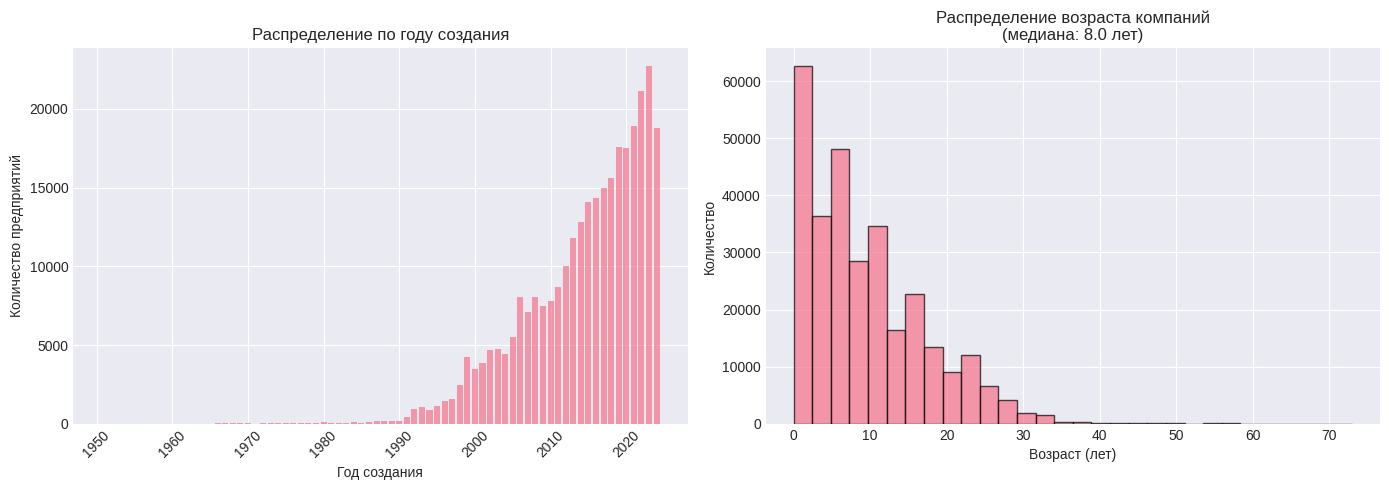

**Статус предприятий:**

- Активные: 267142 (89.0%)

- Ликвидированные: 32858 (11.0%)

## Финансовые КПЭ

/opt/conda/lib/python3.12/site-packages/numpy/core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/opt/conda/lib/python3.12/site-packages/numpy/core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/opt/conda/lib/python3.12/site-packages/numpy/core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/opt/conda/lib/python3.12/site-packages/numpy/core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


**Статистика финансовых коэффициентов:**

,equity_ratio,debt_to_equity,roe,roa
count,1.504490e+05,1.504430e+05,1.507080e+05,1.508190e+05
mean,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN
min,-inf,-inf,-inf,-inf
25%,3.805664e-02,0.000000e+00,8.851282e-02,0.000000e+00
50%,3.842303e-01,4.156627e-01,1.987406e+01,2.816639e+00
75%,8.711168e-01,3.788316e+00,7.566381e+01,1.913360e+01
max,inf,inf,inf,inf


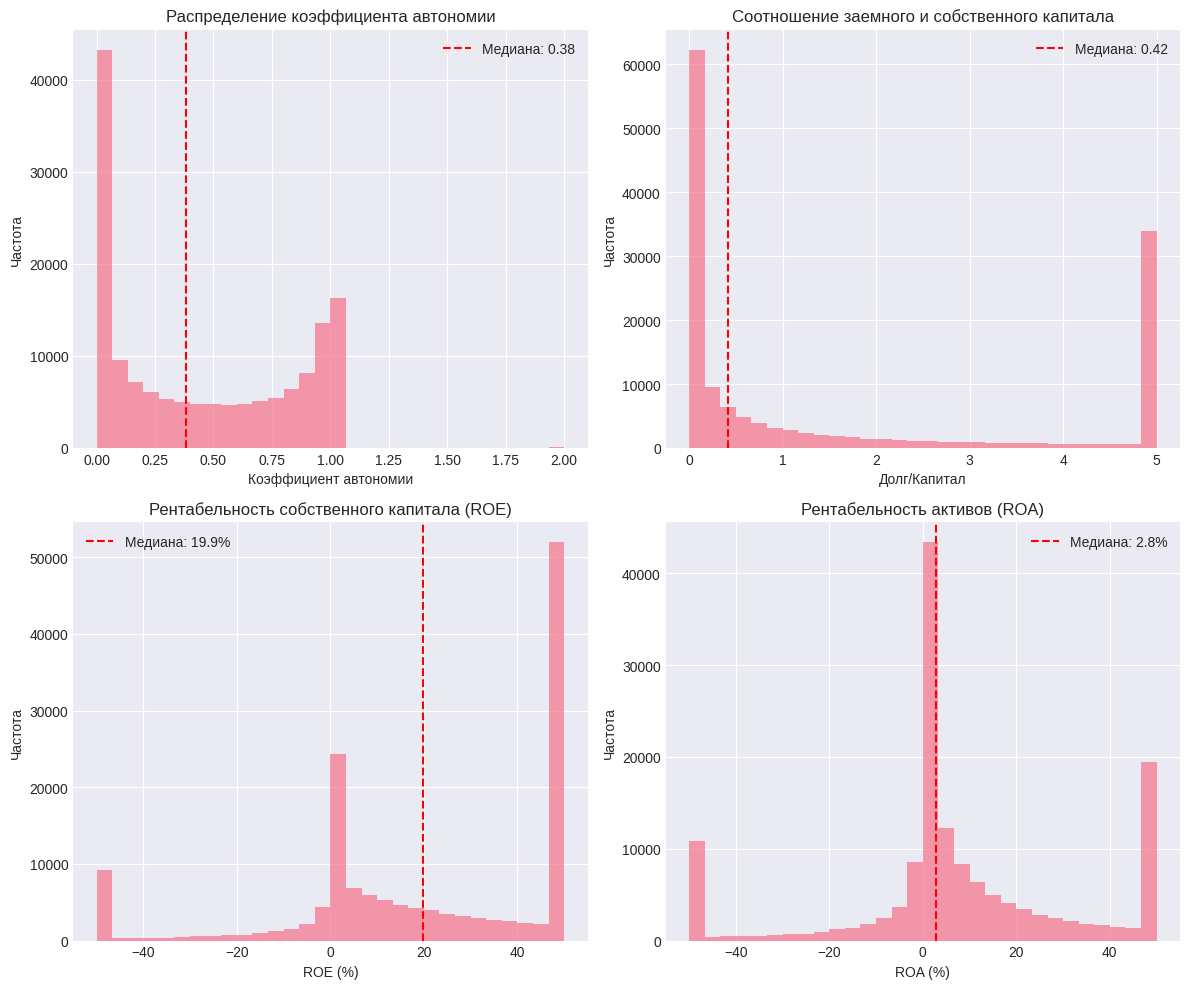

## Географическое распределение

**Предприятия с геоданными:** 298951 (99.7%)

**Топ-10 регионов по количеству предприятий:**

region
tatarstan             90902
bashkortostan         61127
dagestan              22449
yakutia               18327
buryatia              15470
karelia               14809
komi                  10702
kabardino-balkaria     9091
marij el               9045
mordovia               8883
Name: count, dtype: int64

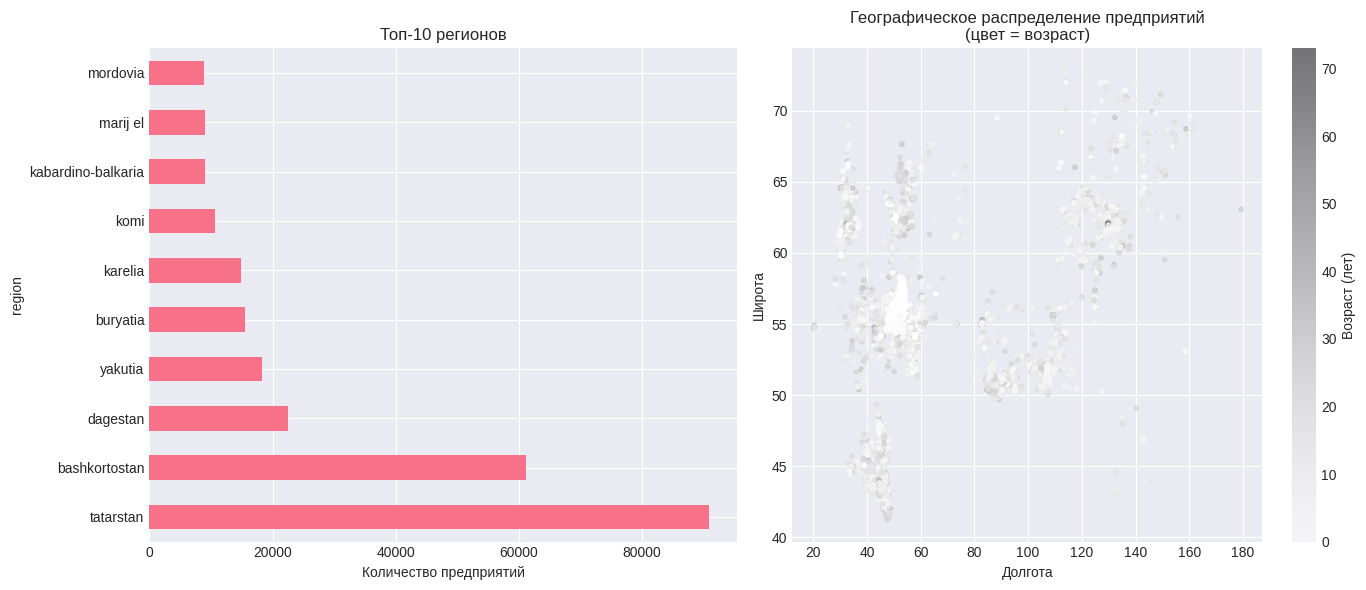

**Качество геокодирования:**

geocoding_quality
street    166304
house      92273
city       40374
Name: count, dtype: int64

## Анализ по ОКВЭД

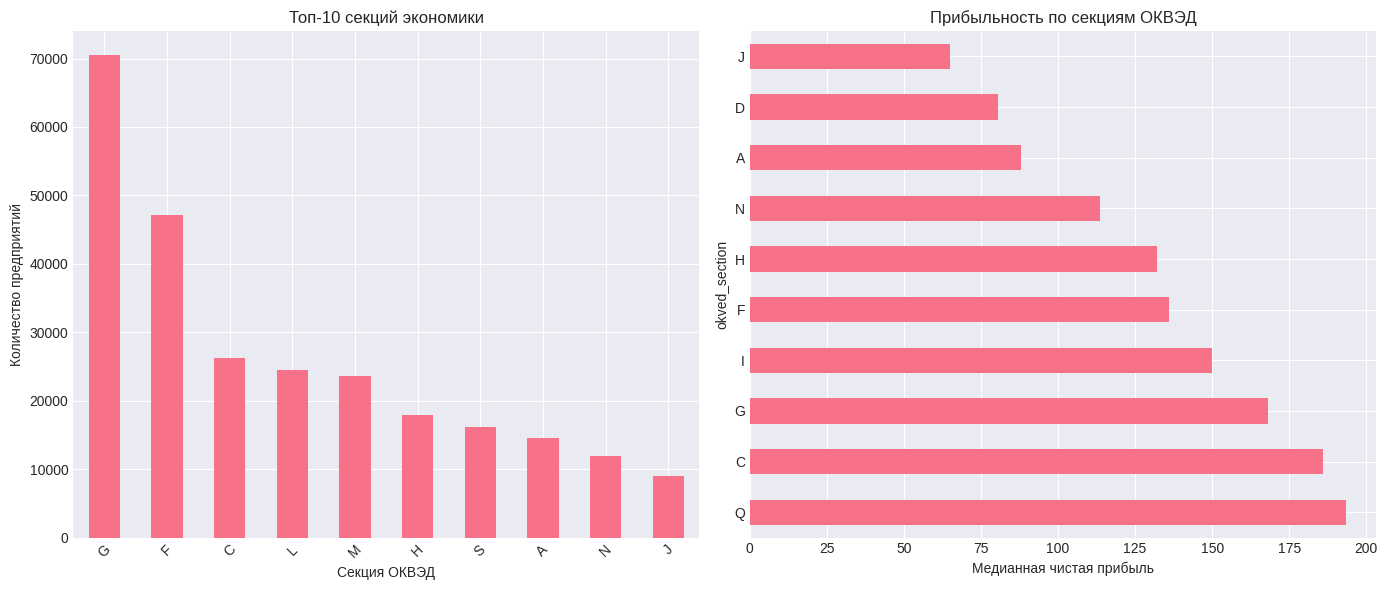

**Детализация по секциям:**

okved_section
G    70472
F    47116
C    26208
L    24416
M    23668
H    17866
S    16163
A    14600
N    11950
J     8963
Name: count, dtype: int64

## Проверка гипотез

### Гипотеза 1: Возраст компании влияет на прибыльность

/tmp/ipykernel_132/2270768770.py:357: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  profit_by_age = df_test.groupby('age_group')['PL_net_profit'].agg(['median', 'mean', 'count'])


,median,mean,count
age_group,,,
0-2,78.0,2583.437359,22190
3-5,113.0,3260.130400,27293
6-10,151.0,5534.695951,40237
11-20,137.0,10410.897651,45120
20+,97.0,31968.829374,16545


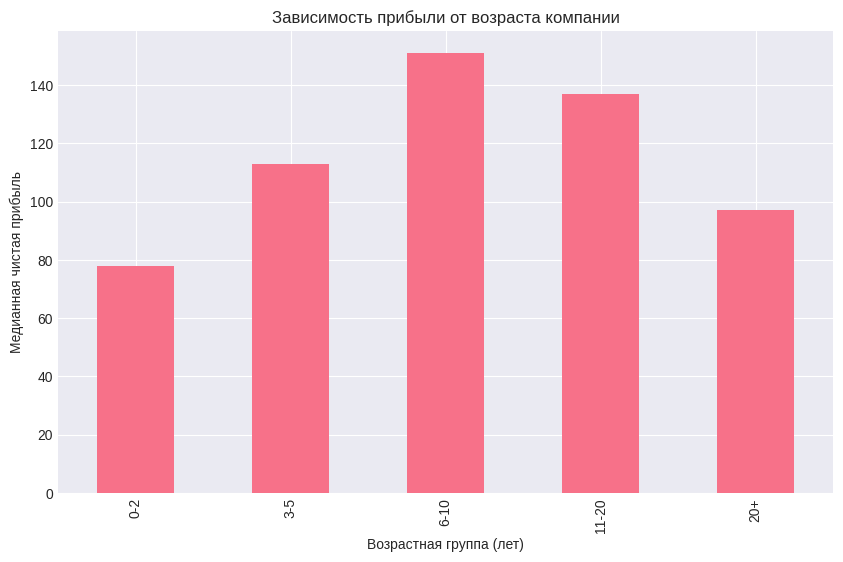

### Гипотеза 2: Существует корреляция между активами и прибылью

**Коэффициент корреляции Пирсона:** 0.685

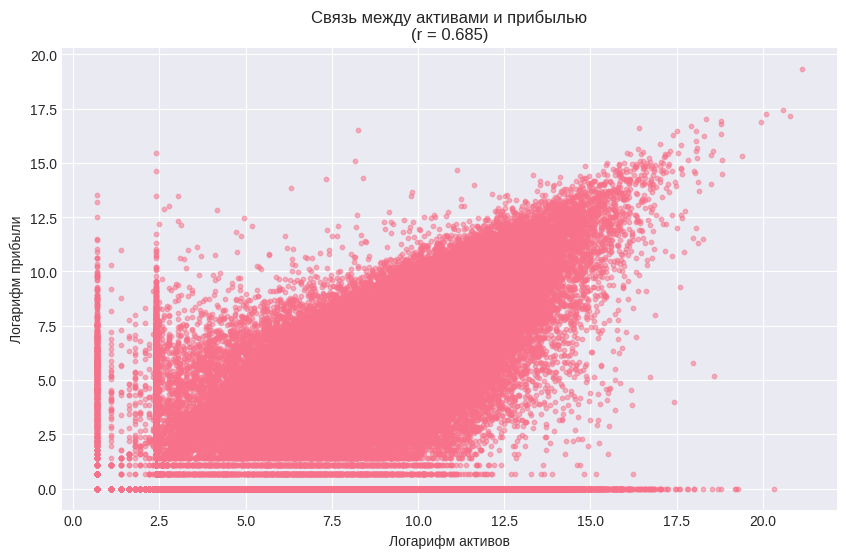

### Гипотеза 3: Прибыльность отличается между налоговыми режимами

**УСН (n=92856):** медиана = 99

**ОСН (n=22):** медиана = 4

/tmp/ipykernel_132/2270768770.py:400: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([usn_profit.clip(lower=usn_profit.quantile(0.05),


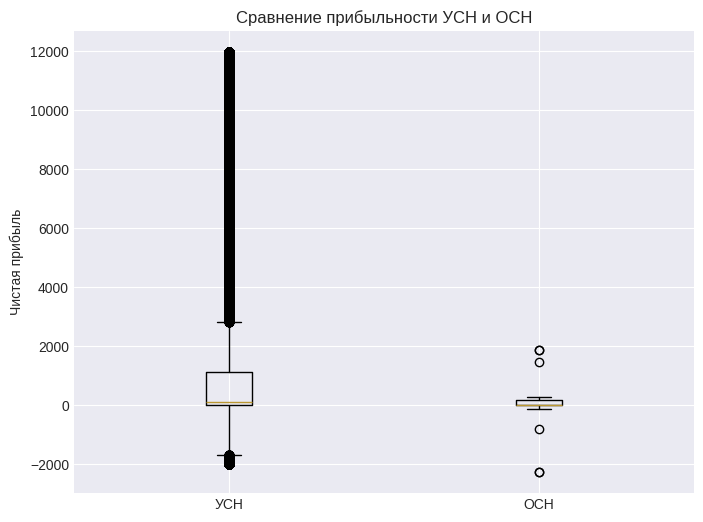

# Итоговый аналитический отчет

## Ключевые выводы

1. **Полнота данных:** 0.0% предприятий имеют полные финансовые данные

2. **Прибыльность:** 105148 предприятий прибыльны (35.0%), медианная прибыль = 110

3. **География:** данные охватывают 85 регионов РФ

4. **Возраст:** медианный возраст 8 лет, молодых компаний (≤3 лет): 81505 (27.2%)

## Рекомендации по дальнейшему анализу


    - Провести детальный анализ прибыльности в разрезе регионов
    - Исследовать динамику финансовых показателей по годам (при наличии временных рядов)
    - Проверить гипотезы о влиянии налогового режима на финансовую устойчивость
    - Построить прогнозные модели для выявления факторов банкротства
    

In [10]:
# %% [markdown]
# # Финансовый анализ российских предприятий
# Анализ бухгалтерской отчетности с географической привязкой

# %% [markdown]
# ## 1. Импорт библиотек и настройки

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Настройки pandas для полного вывода
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Настройки визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# %% [markdown]
# ## 2. Общая информация о датафрейме

# %%
def display_dataframe_info(df, name="dfa"):
    """Выводит общую информацию о датафрейме"""
    display(Markdown(f"### Анализ датафрейма: {name}"))
    
    # Основная информация
    display(Markdown(f"**Форма:** {df.shape[0]} строк × {df.shape[1]} столбцов"))
    
    # Типы данных
    display(Markdown("**Типы данных:**"))
    display(pd.DataFrame({
        'Тип': df.dtypes,
        'Кол-во NaN': df.isnull().sum(),
        '% NaN': (df.isnull().sum() / len(df) * 100).round(2)
    }).sort_values('Тип'))
    
    # Статистика по числовым колонкам
    display(Markdown("**Статистика числовых показателей:**"))
    display(df.describe())

# Применяем к существующему dfa
display_dataframe_info(dfa)

# %% [markdown]
# ## 3. Анализ доступности и качества финансовых данных

# %%
def analyze_financial_availability(df):
    """Анализ наличия финансовых показателей"""
    display(Markdown("## Анализ доступности финансовых данных"))
    
    # Финансовые колонки
    financial_cols = [
        'B_current_assets', 'B_cash_equivalents', 'B_total_equity',
        'B_assets', 'B_liab', 'PL_before_tax', 'PL_net_profit', 'PL_total'
    ]
    
    # Проверка наличия
    availability = {}
    for col in financial_cols:
        if col in df.columns:
            non_null = df[col].notna().sum()
            availability[col] = {
                'Доступно записей': non_null,
                'Доля': f"{non_null / len(df) * 100:.1f}%",
                'Медиана': df[col].median() if non_null > 0 else np.nan
            }
    
    availability_df = pd.DataFrame(availability).T
    display(availability_df)
    
    # Компании с полными данными
    complete_cases = df[financial_cols].dropna()
    display(Markdown(f"**Компании с полными финансовыми данными:** {len(complete_cases)} "
                     f"({len(complete_cases)/len(df)*100:.1f}%)"))
    
    return availability_df

financial_availability = analyze_financial_availability(dfa)

# %% [markdown]
# ## 4. Системные показатели и качество отчетности

# %%
def analyze_system_indicators(df):
    """Анализ системных показателей (налоговый режим, критерии)"""
    display(Markdown("## Системные показатели предприятий"))
    
    # Налоговые режимы
    tax_systems = {
        'simplified': 'УСН (упрощенная)',
        'imputed': 'ЕНВД (вмененная)',
        'financial': 'Общая система'
    }
    
    for col, name in tax_systems.items():
        if col in df.columns:
            count = (df[col] == 1).sum()
            pct = count / len(df) * 100
            display(Markdown(f"- **{name}:** {count} предприятий ({pct:.1f}%)"))
    
    # Критерии освобождения от аудита
    if 'exemption_criteria' in df.columns:
        display(Markdown("**Критерии освобождения от аудита:**"))
        exemption_dist = df['exemption_criteria'].value_counts()
        display(exemption_dist)
    
    # Выбросы и корректировки
    if 'outlier' in df.columns:
        outliers = (df['outlier'] == 1).sum()
        display(Markdown(f"**Выбросы в данных:** {outliers} предприятий ({outliers/len(df)*100:.1f}%)"))
    
    if 'totals_adjustment' in df.columns:
        adjustments = (df['totals_adjustment'] == 1).sum()
        display(Markdown(f"**Скорректированные итоги:** {adjustments} предприятий ({adjustments/len(df)*100:.1f}%)"))

analyze_system_indicators(dfa)

# %% [markdown]
# ## 5. Временные тренды

# %%
def analyze_temporal_trends(df):
    """Анализ трендов по дате создания и возрасту"""
    display(Markdown("## Временные тренды"))
    
    # Преобразование дат
    if 'creation_date' in df.columns:
        df['creation_year'] = pd.to_datetime(df['creation_date'], errors='coerce').dt.year
    
    # Распределение по годам создания
    if 'creation_year' in df.columns and df['creation_year'].notna().any():
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Гистограмма по годам
        year_dist = df['creation_year'].value_counts().sort_index()
        axes[0].bar(year_dist.index, year_dist.values, alpha=0.7)
        axes[0].set_xlabel('Год создания')
        axes[0].set_ylabel('Количество предприятий')
        axes[0].set_title('Распределение по году создания')
        axes[0].tick_params(axis='x', rotation=45)
        
        # Возраст компаний
        if 'age' in df.columns and df['age'].notna().any():
            ages = df['age'].dropna()
            axes[1].hist(ages, bins=30, alpha=0.7, edgecolor='black')
            axes[1].set_xlabel('Возраст (лет)')
            axes[1].set_ylabel('Количество')
            axes[1].set_title(f'Распределение возраста компаний\n(медиана: {ages.median():.1f} лет)')
        
        plt.tight_layout()
        plt.show()
    
    # Активные vs ликвидированные
    if 'dissolution_date' in df.columns:
        dissolved = df['dissolution_date'].notna().sum()
        active = len(df) - dissolved
        display(Markdown(f"**Статус предприятий:**"))
        display(Markdown(f"- Активные: {active} ({active/len(df)*100:.1f}%)"))
        display(Markdown(f"- Ликвидированные: {dissolved} ({dissolved/len(df)*100:.1f}%)"))

analyze_temporal_trends(dfa)

# %% [markdown]
# ## 6. Финансовые КПЭ

# %%
def calculate_financial_kpis(df):
    """Расчет ключевых финансовых показателей"""
    display(Markdown("## Финансовые КПЭ"))
    
    # Создаем копию только с валидными данными
    df_fin = df[['B_assets', 'B_liab', 'B_total_equity', 
                 'PL_net_profit', 'PL_before_tax']].dropna()
    
    if len(df_fin) > 0:
        # Расчет метрик
        df_fin['equity_ratio'] = df_fin['B_total_equity'] / df_fin['B_assets']  # Коэффициент автономии
        df_fin['debt_to_equity'] = (df_fin['B_liab'] - df_fin['B_total_equity']) / df_fin['B_total_equity']
        df_fin['roe'] = df_fin['PL_net_profit'] / df_fin['B_total_equity'] * 100  # ROE в %
        df_fin['roa'] = df_fin['PL_net_profit'] / df_fin['B_assets'] * 100  # ROA в %
        
        # Статистика по КПЭ
        kpis = ['equity_ratio', 'debt_to_equity', 'roe', 'roa']
        stats = df_fin[kpis].describe()
        
        display(Markdown("**Статистика финансовых коэффициентов:**"))
        display(stats)
        
        # Визуализация
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        
        # Equity ratio
        axes[0, 0].hist(df_fin['equity_ratio'].clip(0, 2), bins=30, alpha=0.7)
        axes[0, 0].axvline(df_fin['equity_ratio'].median(), color='red', linestyle='--', 
                          label=f"Медиана: {df_fin['equity_ratio'].median():.2f}")
        axes[0, 0].set_xlabel('Коэффициент автономии')
        axes[0, 0].set_ylabel('Частота')
        axes[0, 0].set_title('Распределение коэффициента автономии')
        axes[0, 0].legend()
        
        # Debt to Equity
        debt_eq = df_fin['debt_to_equity'].clip(0, 5)
        axes[0, 1].hist(debt_eq, bins=30, alpha=0.7)
        axes[0, 1].axvline(df_fin['debt_to_equity'].median(), color='red', linestyle='--',
                          label=f"Медиана: {df_fin['debt_to_equity'].median():.2f}")
        axes[0, 1].set_xlabel('Долг/Капитал')
        axes[0, 1].set_ylabel('Частота')
        axes[0, 1].set_title('Соотношение заемного и собственного капитала')
        axes[0, 1].legend()
        
        # ROE
        roe_clipped = df_fin['roe'].clip(-50, 50)
        axes[1, 0].hist(roe_clipped, bins=30, alpha=0.7)
        axes[1, 0].axvline(df_fin['roe'].median(), color='red', linestyle='--',
                          label=f"Медиана: {df_fin['roe'].median():.1f}%")
        axes[1, 0].set_xlabel('ROE (%)')
        axes[1, 0].set_ylabel('Частота')
        axes[1, 0].set_title('Рентабельность собственного капитала (ROE)')
        axes[1, 0].legend()
        
        # ROA
        roa_clipped = df_fin['roa'].clip(-50, 50)
        axes[1, 1].hist(roa_clipped, bins=30, alpha=0.7)
        axes[1, 1].axvline(df_fin['roa'].median(), color='red', linestyle='--',
                          label=f"Медиана: {df_fin['roa'].median():.1f}%")
        axes[1, 1].set_xlabel('ROA (%)')
        axes[1, 1].set_ylabel('Частота')
        axes[1, 1].set_title('Рентабельность активов (ROA)')
        axes[1, 1].legend()
        
        plt.tight_layout()
        plt.show()
        
        return df_fin
    else:
        display(Markdown("**Недостаточно данных для расчета КПЭ**"))
        return None

df_kpi = calculate_financial_kpis(dfa)

# %% [markdown]
# ## 7. Географический анализ

# %%
def analyze_geography(df):
    """Анализ географического распределения"""
    display(Markdown("## Географическое распределение"))
    
    # Проверка наличия координат
    has_coords = df[['lat', 'lon']].notna().all(axis=1)
    display(Markdown(f"**Предприятия с геоданными:** {has_coords.sum()} "
                     f"({has_coords.sum()/len(df)*100:.1f}%)"))
    
    if has_coords.sum() > 0:
        # Регионы
        display(Markdown("**Топ-10 регионов по количеству предприятий:**"))
        region_stats = df['region'].value_counts().head(10)
        display(region_stats)
        
        # Визуализация регионов
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        
        # Барплот регионов
        region_stats.head(10).plot(kind='barh', ax=axes[0])
        axes[0].set_xlabel('Количество предприятий')
        axes[0].set_title('Топ-10 регионов')
        
        # Карта распределения (простая диаграмма рассеяния)
        df_coords = df[has_coords].dropna(subset=['lat', 'lon'])
        scatter = axes[1].scatter(df_coords['lon'], df_coords['lat'], 
                                 alpha=0.5, s=10, c=df_coords.get('age', 1))
        axes[1].set_xlabel('Долгота')
        axes[1].set_ylabel('Широта')
        axes[1].set_title('Географическое распределение предприятий\n(цвет = возраст)')
        plt.colorbar(scatter, ax=axes[1], label='Возраст (лет)')
        
        plt.tight_layout()
        plt.show()
        
        # Анализ по качеству геокодирования
        if 'geocoding_quality' in df.columns:
            display(Markdown("**Качество геокодирования:**"))
            quality_dist = df['geocoding_quality'].value_counts()
            display(quality_dist)

analyze_geography(dfa)

# %% [markdown]
# ## 8. Анализ по видам деятельности (ОКВЭД)

# %%
def analyze_okved(df):
    """Анализ по видам экономической деятельности"""
    display(Markdown("## Анализ по ОКВЭД"))
    
    if 'okved_section' in df.columns and df['okved_section'].notna().any():
        # Распределение по секциям
        section_dist = df['okved_section'].value_counts().head(10)
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        
        # Барплот секций
        section_dist.plot(kind='bar', ax=axes[0])
        axes[0].set_xlabel('Секция ОКВЭД')
        axes[0].set_ylabel('Количество предприятий')
        axes[0].set_title('Топ-10 секций экономики')
        axes[0].tick_params(axis='x', rotation=45)
        
        # Средняя прибыль по секциям (если есть данные)
        if 'PL_net_profit' in df.columns:
            profit_by_section = df.groupby('okved_section')['PL_net_profit'].agg(['median', 'count'])
            profit_by_section = profit_by_section[profit_by_section['count'] >= 5]
            profit_by_section = profit_by_section.sort_values('median', ascending=False).head(10)
            
            if len(profit_by_section) > 0:
                profit_by_section['median'].plot(kind='barh', ax=axes[1])
                axes[1].set_xlabel('Медианная чистая прибыль')
                axes[1].set_title('Прибыльность по секциям ОКВЭД')
        
        plt.tight_layout()
        plt.show()
        
        display(Markdown("**Детализация по секциям:**"))
        display(section_dist)

analyze_okved(dfa)

# %% [markdown]
# ## 9. Гипотезы и корреляционный анализ

# %%
def test_hypotheses(df):
    """Проверка статистических гипотез"""
    display(Markdown("## Проверка гипотез"))
    
    # Подготовка данных
    df_test = df[['age', 'B_assets', 'PL_net_profit', 'eligible']].dropna()
    
    if len(df_test) > 100:
        # Гипотеза 1: Связь возраста компании с прибыльностью
        display(Markdown("### Гипотеза 1: Возраст компании влияет на прибыльность"))
        
        # Группировка по возрасту
        df_test['age_group'] = pd.cut(df_test['age'], bins=[0, 2, 5, 10, 20, 100], 
                                      labels=['0-2', '3-5', '6-10', '11-20', '20+'])
        
        profit_by_age = df_test.groupby('age_group')['PL_net_profit'].agg(['median', 'mean', 'count'])
        display(profit_by_age)
        
        # Визуализация
        fig, ax = plt.subplots(figsize=(10, 6))
        profit_by_age['median'].plot(kind='bar', ax=ax)
        ax.set_xlabel('Возрастная группа (лет)')
        ax.set_ylabel('Медианная чистая прибыль')
        ax.set_title('Зависимость прибыли от возраста компании')
        plt.show()
        
        # Гипотеза 2: Размер активов коррелирует с прибылью
        display(Markdown("### Гипотеза 2: Существует корреляция между активами и прибылью"))
        
        # Корреляция
        correlation = df_test['B_assets'].corr(df_test['PL_net_profit'])
        display(Markdown(f"**Коэффициент корреляции Пирсона:** {correlation:.3f}"))
        
        # Визуализация
        fig, ax = plt.subplots(figsize=(10, 6))
        # Логарифмическая шкала для лучшей визуализации
        log_assets = np.log1p(df_test['B_assets'].clip(lower=1))
        log_profit = np.log1p(df_test['PL_net_profit'].clip(lower=0))
        
        ax.scatter(log_assets, log_profit, alpha=0.5, s=10)
        ax.set_xlabel('Логарифм активов')
        ax.set_ylabel('Логарифм прибыли')
        ax.set_title(f'Связь между активами и прибылью\n(r = {correlation:.3f})')
        plt.show()
        
        # Гипотеза 3: Различия между УСН и общей системой
        if 'simplified' in df.columns and 'PL_net_profit' in df.columns:
            display(Markdown("### Гипотеза 3: Прибыльность отличается между налоговыми режимами"))
            
            usn_profit = df[df['simplified'] == 1]['PL_net_profit'].dropna()
            osn_profit = df[(df['simplified'] == 0) & (df['financial'] == 1)]['PL_net_profit'].dropna()
            
            if len(usn_profit) > 0 and len(osn_profit) > 0:
                display(Markdown(f"**УСН (n={len(usn_profit)}):** медиана = {usn_profit.median():.0f}"))
                display(Markdown(f"**ОСН (n={len(osn_profit)}):** медиана = {osn_profit.median():.0f}"))
                
                # Простая визуализация
                fig, ax = plt.subplots(figsize=(8, 6))
                ax.boxplot([usn_profit.clip(lower=usn_profit.quantile(0.05), 
                                            upper=usn_profit.quantile(0.95)),
                           osn_profit.clip(lower=osn_profit.quantile(0.05),
                                          upper=osn_profit.quantile(0.95))],
                          labels=['УСН', 'ОСН'])
                ax.set_ylabel('Чистая прибыль')
                ax.set_title('Сравнение прибыльности УСН и ОСН')
                plt.show()

test_hypotheses(dfa)

# %% [markdown]
# ## 10. Итоговое резюме

# %%
def summary_report(df):
    """Формирование итогового отчета"""
    display(Markdown("# Итоговый аналитический отчет"))
    
    # Основные метрики
    display(Markdown("## Ключевые выводы"))
    
    # Доступность данных
    fin_cols = ['B_assets', 'PL_net_profit']
    fin_completeness = sum(df[col].notna().all() for col in fin_cols)
    
    display(Markdown(f"1. **Полнота данных:** {fin_completeness/len(df)*100:.1f}% предприятий имеют "
                     f"полные финансовые данные"))
    
    # Средние показатели
    if 'PL_net_profit' in df.columns and df['PL_net_profit'].notna().any():
        median_profit = df['PL_net_profit'].median()
        profitable = (df['PL_net_profit'] > 0).sum()
        display(Markdown(f"2. **Прибыльность:** {profitable} предприятий прибыльны "
                         f"({profitable/len(df):.1%}), медианная прибыль = {median_profit:,.0f}"))
    
    # География
    regions = df['region'].nunique() if 'region' in df.columns else 0
    display(Markdown(f"3. **География:** данные охватывают {regions} регионов РФ"))
    
    # Возрастной состав
    if 'age' in df.columns and df['age'].notna().any():
        median_age = df['age'].median()
        young = (df['age'] <= 3).sum()
        display(Markdown(f"4. **Возраст:** медианный возраст {median_age:.0f} лет, "
                         f"молодых компаний (≤3 лет): {young} ({young/len(df):.1%})"))
    
    # Рекомендации
    display(Markdown("## Рекомендации по дальнейшему анализу"))
    display(Markdown("""
    - Провести детальный анализ прибыльности в разрезе регионов
    - Исследовать динамику финансовых показателей по годам (при наличии временных рядов)
    - Проверить гипотезы о влиянии налогового режима на финансовую устойчивость
    - Построить прогнозные модели для выявления факторов банкротства
    """))

summary_report(dfa)

#### 3.5. Московская гипотеза

Спросим мнение у ИИ:

```prompt

## Входные данные
- датафрейм `dfa` с данными бухгалтерской отчетности российских предприятий

## Задача
- протестировать гипотезу о зависимости размера компании и ее рентабельности активов и капитала от расстояния до Москвы
- для тестирования необходимо сделать колонку с расстоянием до Москвы
- расстояние рассчитать как евклидово расстояние на основе широты lat и долготы lon из данных
- координаты Москвы взять mow_lat=55.7522° mow_lon=37.6156°

## Технические ограничения
- использовать библиотеку Pandas и ее встроенные методы и функции
- настрой pandas так, чтобы выводились все столбцы, без пропусков
- код запускается в интерактивном ноутбуке Jupyter

## Технические требования
- архитектура: максимально упрощенная
- вывод данных: адаптированный под интерактивные ноутбуки, где возможно используй display вместо print 
- стиль кода: PEP 8, black (длина строки 79)
- документация: Docstrings в стиле Google

```

In [11]:
# -*- coding: utf-8 -*-
"""Анализ зависимости размера компании и рентабельности от расстояния до Москвы."""

import pandas as pd
import numpy as np

# Настройка pandas для отображения всех столбцов
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_rows', 100)

# Координаты Москвы
MOW_LAT = 55.7522
MOW_LON = 37.6156


def calculate_distance_to_moscow(lat: pd.Series, lon: pd.Series) -> pd.Series:
    """
    Расчет евклидова расстояния до Москвы по координатам.

    Parameters
    ----------
    lat : pd.Series
        Широта предприятия
    lon : pd.Series
        Долгота предприятия

    Returns
    -------
    pd.Series
        Евклидово расстояние в градусах
    """
    return np.sqrt((lat - MOW_LAT) ** 2 + (lon - MOW_LON) ** 2)


def add_distance_column(df: pd.DataFrame) -> pd.DataFrame:
    """
    Добавление колонки с расстоянием до Москвы в датафрейм.

    Parameters
    ----------
    df : pd.DataFrame
        Исходный датафрейм с колонками lat и lon

    Returns
    -------
    pd.DataFrame
        Датафрейм с добавленной колонкой distance_to_moscow
    """
    df_copy = df.copy()
    df_copy['distance_to_moscow'] = calculate_distance_to_moscow(
        df_copy['lat'], df_copy['lon']
    )
    return df_copy


def calculate_roe(series: pd.Series) -> pd.Series:
    """
    Расчет рентабельности собственного капитала (ROE).

    Parameters
    ----------
    series : pd.Series
        Кортеж из чистой прибыли и собственного капитала

    Returns
    -------
    pd.Series
        ROE или NaN при делении на ноль
    """
    net_profit, total_equity = series
    if total_equity == 0 or pd.isna(total_equity) or pd.isna(net_profit):
        return np.nan
    return net_profit / total_equity


def prepare_data_for_analysis(df: pd.DataFrame) -> pd.DataFrame:
    """
    Подготовка данных для анализа: создание метрик размера и рентабельности.

    Parameters
    ----------
    df : pd.DataFrame
        Исходный датафрейм

    Returns
    -------
    pd.DataFrame
        Подготовленный датафрейм с метриками
    """
    # Копируем данные
    df_clean = df.copy()
    
    # Добавляем расстояние до Москвы
    df_clean = add_distance_column(df_clean)
    
    # Создаем метрику размера компании (логарифм активов)
    df_clean['company_size'] = np.log(df_clean['B_assets'])
    
    # Создаем метрику рентабельности (ROE)
    df_clean['roe'] = df_clean.apply(
        lambda row: calculate_roe((row['PL_net_profit'], row['B_total_equity'])),
        axis=1
    )
    
    return df_clean


def analyze_correlations(df: pd.DataFrame) -> None:
    """
    Анализ корреляций между расстоянием, размером и рентабельностью.

    Parameters
    ----------
    df : pd.DataFrame
        Подготовленный датафрейм
    """
    from IPython.display import display
    
    # Выбираем релевантные колонки
    analysis_cols = ['distance_to_moscow', 'company_size', 'roe']
    df_analysis = df[analysis_cols].dropna()
    
    # Расчет корреляций
    correlations = df_analysis.corr()
    
    print("=" * 79)
    print("АНАЛИЗ ЗАВИСИМОСТИ РАЗМЕРА И РЕНТАБЕЛЬНОСТИ ОТ РАССТОЯНИЯ ДО МОСКВЫ")
    print("=" * 79)
    print(f"\nКоличество предприятий в анализе: {len(df_analysis)}")
    print("\nСтатистика по расстоянию до Москвы (градусы):")
    display(df_analysis['distance_to_moscow'].describe())
    
    print("\nСтатистика по размеру компании (логарифм активов):")
    display(df_analysis['company_size'].describe())
    
    print("\nСтатистика по рентабельности (ROE):")
    display(df_analysis['roe'].describe())
    
    print("\n" + "=" * 79)
    print("КОРРЕЛЯЦИОННАЯ МАТРИЦА")
    print("=" * 79)
    display(correlations)
    
    print("\nИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ:")
    print("-" * 79)
    
    # Проверяем гипотезы
    dist_size_corr = correlations.loc['distance_to_moscow', 'company_size']
    dist_roe_corr = correlations.loc['distance_to_moscow', 'roe']
    
    print(f"\n1. Корреляция 'расстояние-размер': {dist_size_corr:.3f}")
    if abs(dist_size_corr) < 0.1:
        print("   → Нет значимой зависимости между расстоянием до Москвы и размером компании")
    elif dist_size_corr > 0:
        print(f"   → Слабая положительная связь: чем дальше от Москвы, тем крупнее компании")
    else:
        print(f"   → Слабая отрицательная связь: чем ближе к Москве, тем крупнее компании")
    
    print(f"\n2. Корреляция 'расстояние-рентабельность': {dist_roe_corr:.3f}")
    if abs(dist_roe_corr) < 0.1:
        print("   → Нет значимой зависимости между расстоянием до Москвы и рентабельностью")
    elif dist_roe_corr > 0:
        print(f"   → Слабая положительная связь: чем дальше от Москвы, тем выше рентабельность")
    else:
        print(f"   → Слабая отрицательная связь: чем ближе к Москве, тем выше рентабельность")


def main(dfa: pd.DataFrame) -> None:
    """
    Основная функция анализа.

    Parameters
    ----------
    dfa : pd.DataFrame
        Исходный датафрейм с данными предприятий
    """
    # Подготовка данных
    df_prepared = prepare_data_for_analysis(dfa)
    
    # Анализ корреляций
    analyze_correlations(df_prepared)
    
    # Возвращаем подготовленные данные для дальнейшего анализа
    return df_prepared


# Выполнение анализа
if __name__ == "__main__" or 'dfa' in globals():
    # Проверяем наличие данных
    try:
        prepared_data = main(dfa)
    except NameError:
        print("Ошибка: датафрейм 'dfa' не найден в глобальной области видимости")

/opt/conda/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/conda/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


АНАЛИЗ ЗАВИСИМОСТИ РАЗМЕРА И РЕНТАБЕЛЬНОСТИ ОТ РАССТОЯНИЯ ДО МОСКВЫ

Количество предприятий в анализе: 150977

Статистика по расстоянию до Москвы (градусы):


count    150977.000000
mean         21.094153
std          21.112799
min           0.002506
25%          11.514296
50%          14.550745
75%          18.399301
max         124.456636
Name: distance_to_moscow, dtype: float64


Статистика по размеру компании (логарифм активов):


count    1.509770e+05
mean             -inf
std               NaN
min              -inf
25%      6.678342e+00
50%      8.700348e+00
75%      1.034464e+01
max      2.112413e+01
Name: company_size, dtype: float64


Статистика по рентабельности (ROE):


count    150977.000000
mean          9.969816
std        1528.346032
min      -94840.800000
25%           0.000000
50%           0.190476
75%           0.737190
max      515845.400000
Name: roe, dtype: float64


КОРРЕЛЯЦИОННАЯ МАТРИЦА


,distance_to_moscow,company_size,roe
distance_to_moscow,1.000000,-0.049167,-0.001303
company_size,-0.049167,1.000000,-0.009413
roe,-0.001303,-0.009413,1.000000



ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ:
-------------------------------------------------------------------------------

1. Корреляция 'расстояние-размер': -0.049
   → Нет значимой зависимости между расстоянием до Москвы и размером компании

2. Корреляция 'расстояние-рентабельность': -0.001
   → Нет значимой зависимости между расстоянием до Москвы и рентабельностью


#### 3.6. Визуализация геоданных



```prompt

## Входные данные
- датафрейм `dfa` с данными бухгалтерской отчетности российских предприятий

## Задача
- выбрать случайную подвыборку из датафрейма размером 1000 точек, чтобы не перегружать диаграмму
- размер подвыборки задай единым гиперпараметром SAMPLE_SIZE 
- визуализировать основные показатели через геоданные в виде пузырьковых диаграмм
- широта и долгота как оси диаграммы, размер пузырька отражает значение
- обрати внимание на геоданные (широта lat и долгота lon) в датасете
- рисуй диаграммы на всю ширину страницы
- визуализация стандартными библиотеками Python

## Технические ограничения
- код запускается в интерактивном ноутбуке Jupyter
- визуализация стандартными библиотеками Python

## Технические требования
- архитектура: максимально упрощенная
- стиль кода: PEP 8, black (длина строки 79)
- документация: Docstrings в стиле Google

```

Исходный размер датафрейма: 300000 записей
Размер подвыборки: 10000 записей
После очистки геоданных: 9961 записей

--- Создание пузырьковых диаграмм ---

Визуализация: Баланс (актив), тыс. руб.


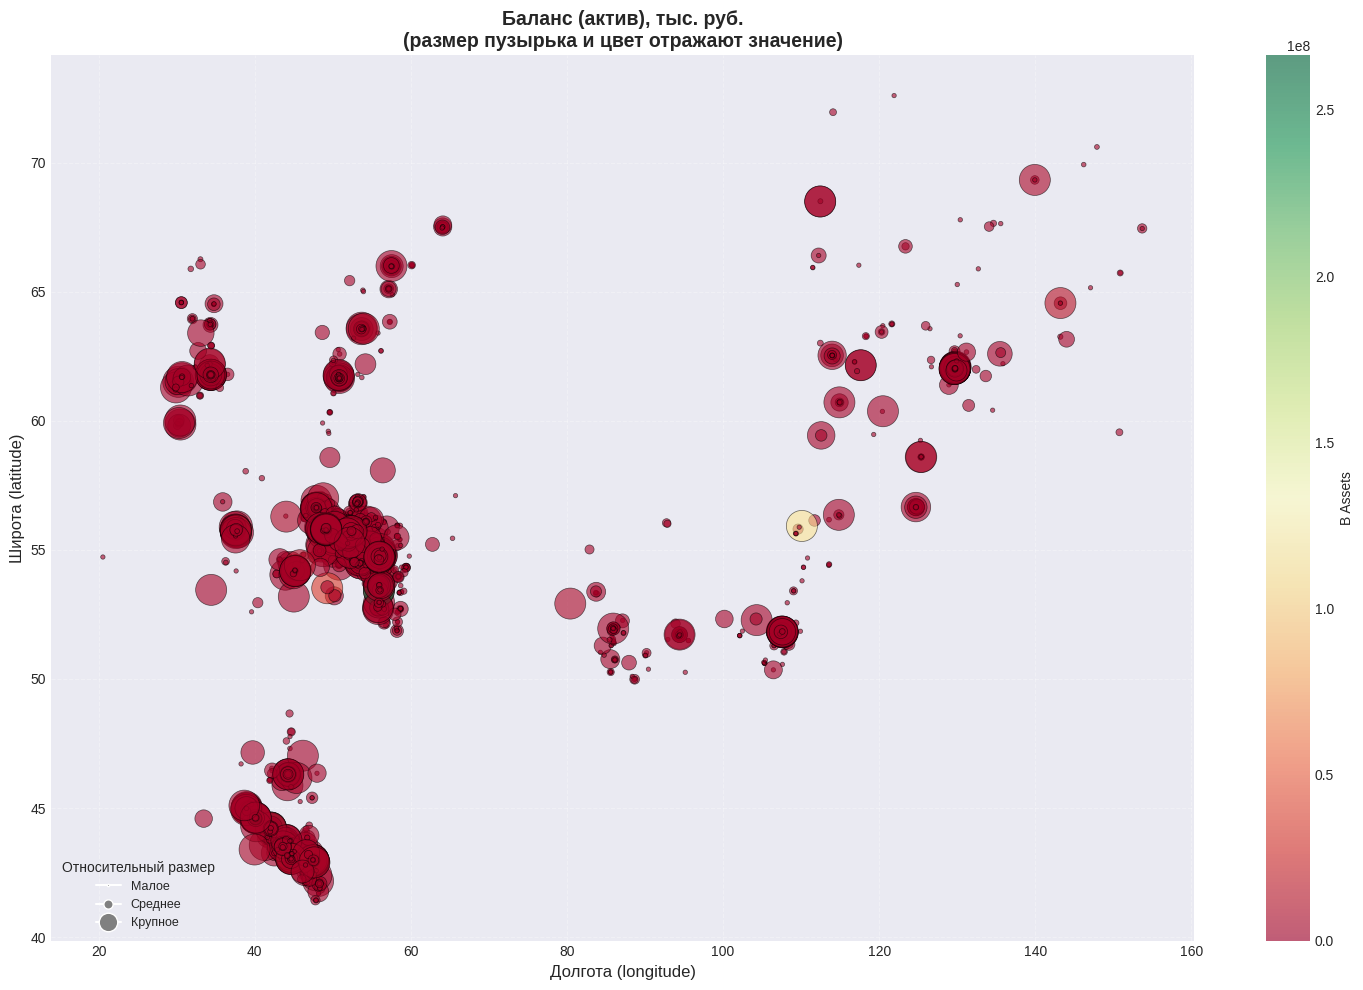

Визуализация: Итого капитал, тыс. руб.


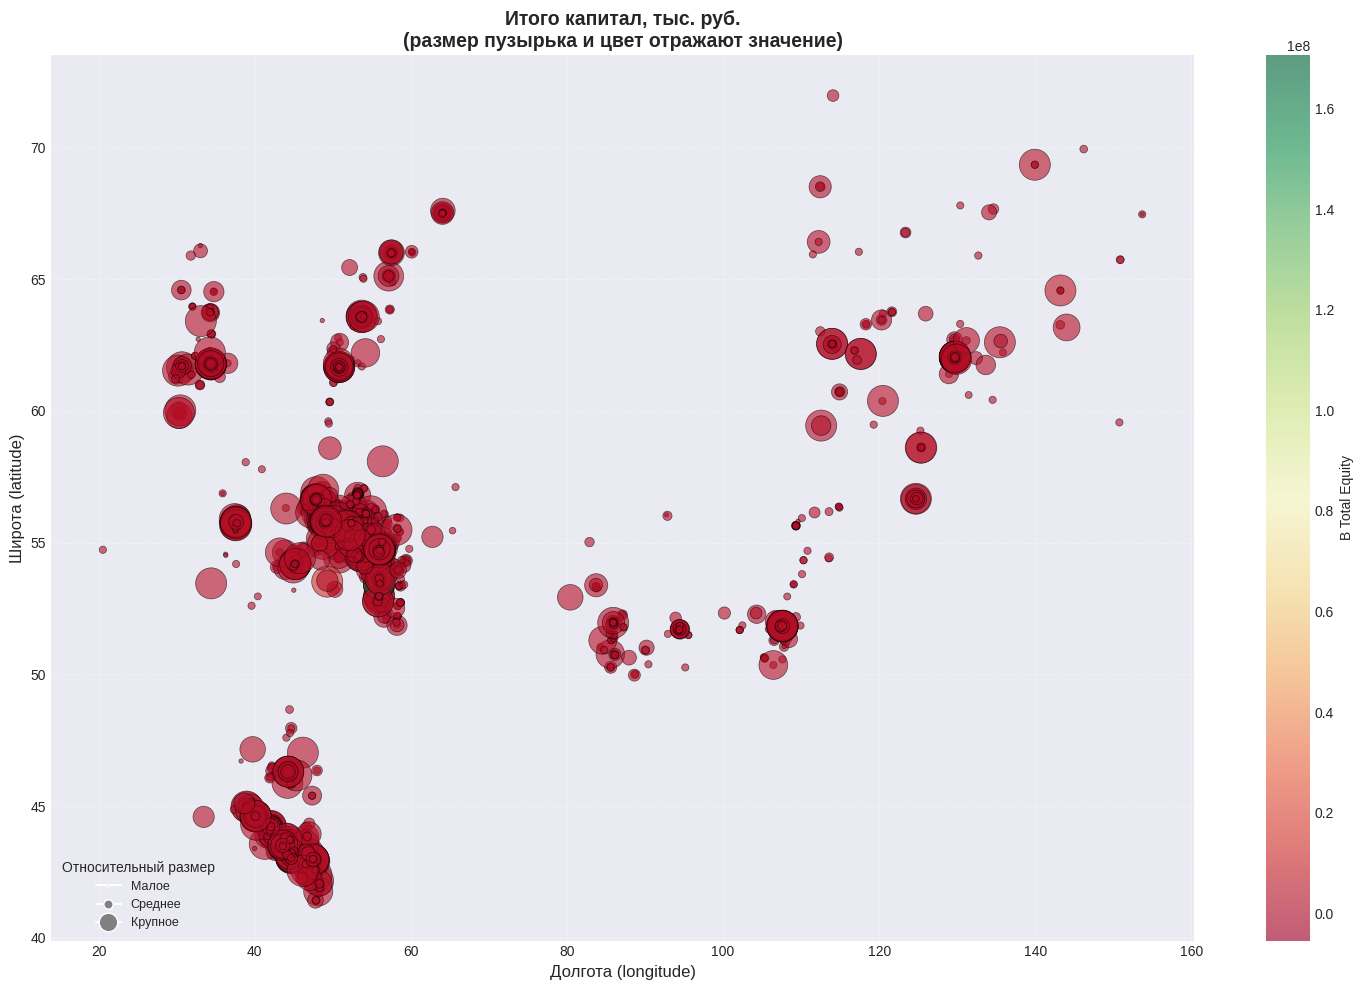

Визуализация: Чистая прибыль (убыток), тыс. руб.


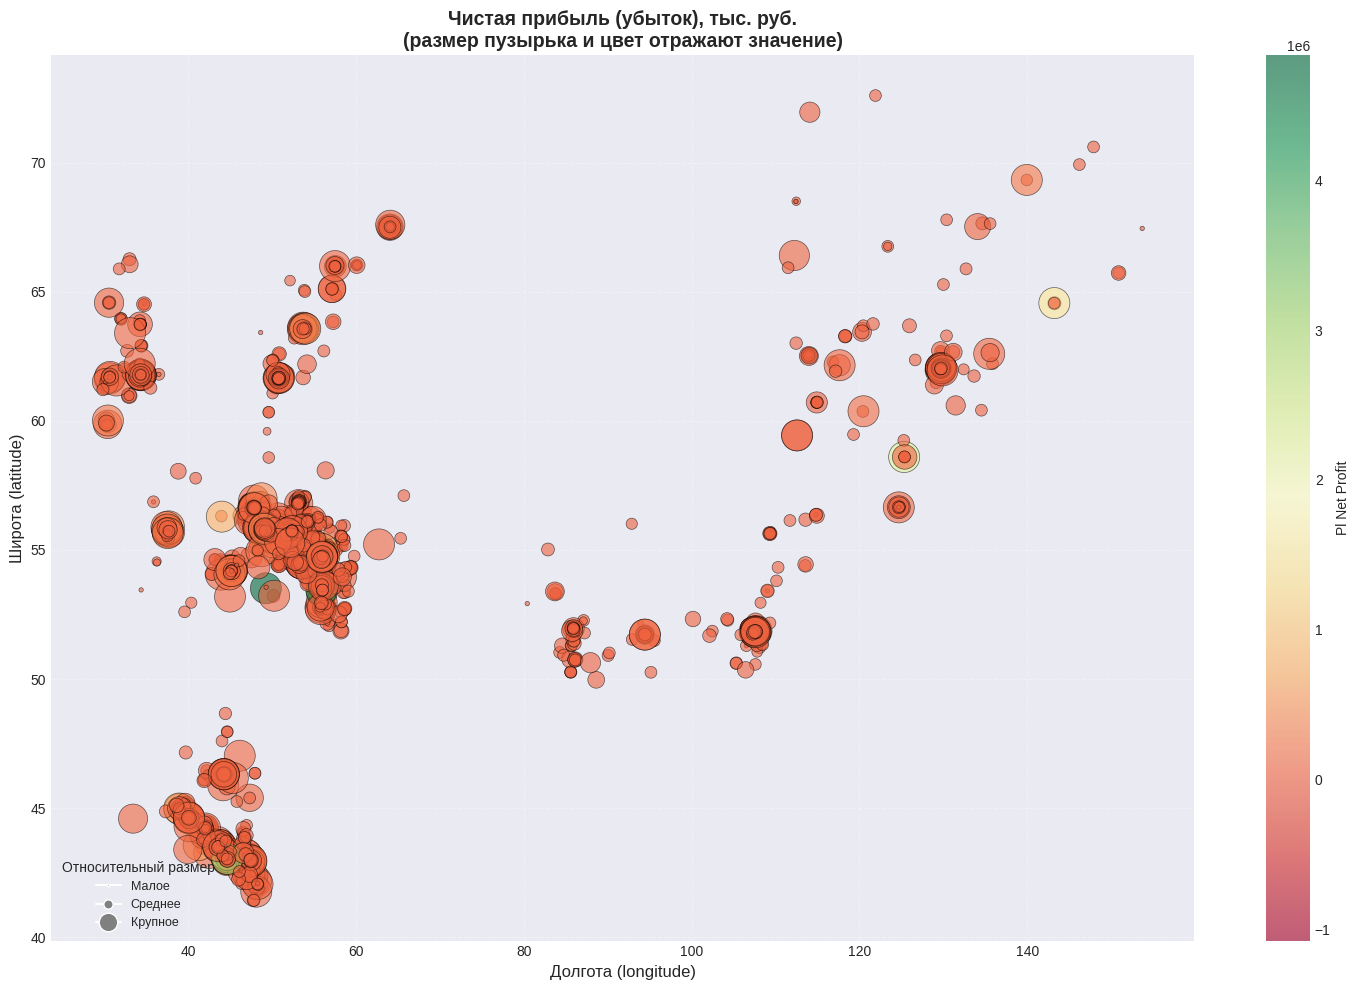

In [12]:
# %% [markdown]
# # Визуализация финансовых показателей на географической карте
# 
# Пузырьковая диаграмма с координатами (долгота, широта)

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

# %% [markdown]
# ## Настройка гиперпараметров

# %%
# Гиперпараметры
SAMPLE_SIZE = 10000  # Размер случайной подвыборки

# Настройки визуализации
FIGURE_WIDTH = 15   # Ширина фигуры в дюймах
FIGURE_HEIGHT = 10  # Высота фигуры в дюймах

# Список показателей для визуализации
METRICS = {
    "B_assets": "Баланс (актив), тыс. руб.",
    "B_total_equity": "Итого капитал, тыс. руб.",
    "PL_net_profit": "Чистая прибыль (убыток), тыс. руб.",
}

# %%
def clean_geodata(df: pd.DataFrame) -> pd.DataFrame:
    """
    Очистка геоданных от выбросов и пропусков.
    
    Args:
        df: Исходный датафрейм с колонками lon, lat
        
    Returns:
        Очищенный датафрейм с валидными координатами
    """
    # Копируем данные
    df_clean = df.copy()
    
    # Удаляем строки с пропущенными координатами
    df_clean = df_clean.dropna(subset=["lon", "lat"])
    
    # Фильтруем координаты по реальным границам России
    lon_min, lon_max = 19.0, 190.0
    lat_min, lat_max = 41.0, 82.0
    
    df_clean = df_clean[
        (df_clean["lon"] >= lon_min) & (df_clean["lon"] <= lon_max) &
        (df_clean["lat"] >= lat_min) & (df_clean["lat"] <= lat_max)
    ]
    
    return df_clean


def create_bubble_chart(
    df: pd.DataFrame,
    metric: str,
    title: str,
    figsize: tuple = (FIGURE_WIDTH, FIGURE_HEIGHT),
) -> None:
    """
    Создание пузырьковой диаграммы на географической основе.
    
    Args:
        df: Датафрейм с колонками lon, lat и целевым показателем
        metric: Название колонки с целевым показателем
        title: Заголовок диаграммы
        figsize: Размер фигуры (ширина, высота) в дюймах
    """
    # Удаляем пропуски в целевом показателе
    df_plot = df.dropna(subset=[metric]).copy()
    
    if df_plot.empty:
        print(f"Нет данных для показателя: {metric}")
        return
    
    # Нормализация размера пузырьков (от 10 до 500 точек)
    values = df_plot[metric].values
    # Защита от выбросов: используем перцентили
    vmin = np.percentile(values, 5)
    vmax = np.percentile(values, 95)
    
    # Клиппинг значений для нормализации
    values_clipped = np.clip(values, vmin, vmax)
    
    # Нормализация и масштабирование
    sizes = 10 + 490 * (values_clipped - vmin) / (vmax - vmin)
    
    # Создание фигуры
    fig, ax = plt.subplots(figsize=figsize)
    
    # Пузырьковая диаграмма
    scatter = ax.scatter(
        df_plot["lon"],
        df_plot["lat"],
        s=sizes,
        c=df_plot[metric],
        cmap="RdYlGn",
        alpha=0.6,
        edgecolors="black",
        linewidth=0.5,
    )
    
    # Добавление цветовой шкалы
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label(metric.replace("_", " ").title(), fontsize=10)
    
    # Настройка осей
    ax.set_xlabel("Долгота (longitude)", fontsize=12)
    ax.set_ylabel("Широта (latitude)", fontsize=12)
    ax.set_title(title, fontsize=14, fontweight="bold")
    
    # Добавление легенды для размеров
    legend_sizes = [50, 200, 400]
    legend_labels = ["Малое", "Среднее", "Крупное"]
    
    legend_elements = [
        Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor="gray",
            markersize=size / 30,
            label=label,
        )
        for size, label in zip(legend_sizes, legend_labels)
    ]
    
    ax.legend(
        handles=legend_elements,
        title="Относительный размер",
        loc="lower left",
        fontsize=9,
    )
    
    # Сетка
    ax.grid(True, alpha=0.3, linestyle="--")
    
    plt.tight_layout()
    plt.show()


def main(dfa: pd.DataFrame) -> None:
    """
    Основная функция: выборка и визуализация показателей.
    
    Args:
        dfa: Исходный датафрейм с данными организаций
    """
    print(f"Исходный размер датафрейма: {len(dfa)} записей")
    
    # Шаг 1: Выбор случайной подвыборки
    if len(dfa) > SAMPLE_SIZE:
        df_sample = dfa.sample(n=SAMPLE_SIZE, random_state=42)
        print(f"Размер подвыборки: {len(df_sample)} записей")
    else:
        df_sample = dfa.copy()
        print(f"Размер датафрейма меньше {SAMPLE_SIZE}, используем все данные")
    
    # Шаг 2: Очистка геоданных
    df_clean = clean_geodata(df_sample)
    print(f"После очистки геоданных: {len(df_clean)} записей")
    
    # Шаг 3: Визуализация показателей
    print("\n--- Создание пузырьковых диаграмм ---\n")
    
    for metric, description in METRICS.items():
        if metric in df_clean.columns:
            print(f"Визуализация: {description}")
            create_bubble_chart(
                df_clean,
                metric,
                f"{description}\n(размер пузырька и цвет отражают значение)",
            )
        else:
            print(f"Показатель '{metric}' отсутствует в данных")


# %%
# Выполнение основной функции
main(dfa)